4. Perform ViT inference on small datasets and compare with CNNs

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import timm
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [2]:
# Load CIFAR-10 Dataset (The "Small Dataset")
# ViT requires resizing to 224x224 (Standard ImageNet resolution)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# CNN works natively on 32x32
transform_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Loading CIFAR-10 Test Set...")
testset_vit = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_vit)
loader_vit = torch.utils.data.DataLoader(testset_vit, batch_size=32, shuffle=False)

testset_cnn = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_cnn)
loader_cnn = torch.utils.data.DataLoader(testset_cnn, batch_size=32, shuffle=False)

Loading CIFAR-10 Test Set...


100%|██████████| 170M/170M [00:03<00:00, 48.9MB/s]


In [3]:
# Load Models
# ViT: Pre-trained on ImageNet-21k, Fine-tuned on CIFAR-10
vit_model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=10).to(device)
vit_model.eval()

# CNN: ResNet-20 trained on CIFAR-10
cnn_model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True).to(device)
cnn_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/hub.py:335: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt


100%|██████████| 1.09M/1.09M [00:00<00:00, 36.2MB/s]


CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

In [4]:
# Inference Function
def run_inference(model, loader, name):
    preds, targets = [], []
    start = time.time()

    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.numpy())

            if i >= 10: break # Limit to 10 batches for quick demo

    total_time = (time.time() - start) * 1000 # ms
    acc = accuracy_score(targets, preds) * 100
    print(f"{name} Results: Accuracy = {acc:.2f}% | Time = {total_time:.1f}ms")
    return preds, targets

In [5]:
# Execute
print("\nComparison")
vit_preds, vit_true = run_inference(vit_model, loader_vit, "ViT")
cnn_preds, cnn_true = run_inference(cnn_model, loader_cnn, "CNN")


Comparison
ViT Results: Accuracy = 7.10% | Time = 251981.6ms
CNN Results: Accuracy = 80.68% | Time = 904.0ms


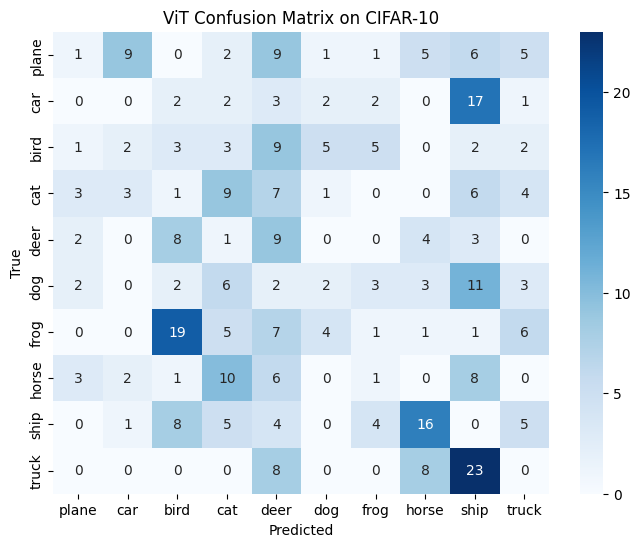

In [6]:
# Generate Plots (Confusion Matrix)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
cm = confusion_matrix(vit_true, vit_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("ViT Confusion Matrix on CIFAR-10")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

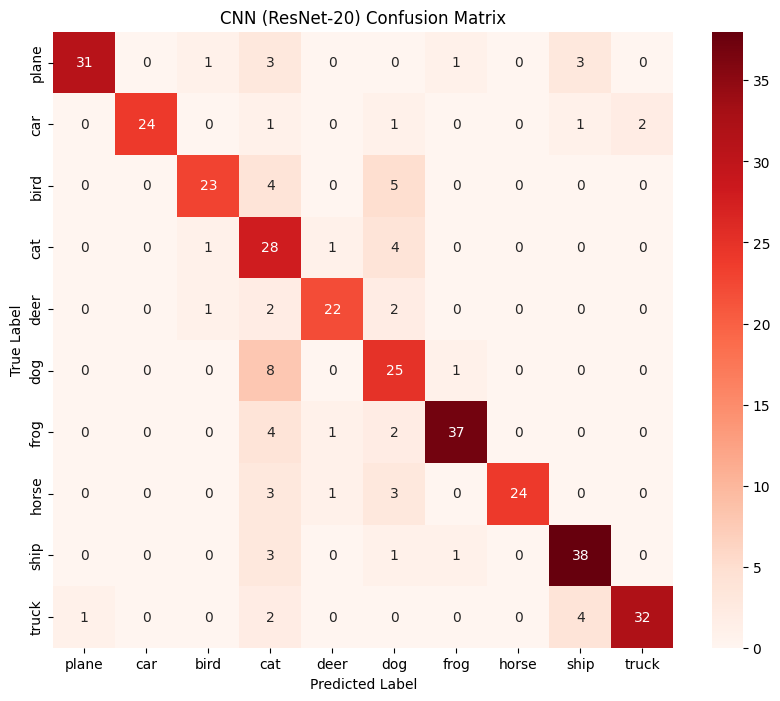

In [8]:

# CNN Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(cnn_true, cnn_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes)
plt.title("CNN (ResNet-20) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Predictions


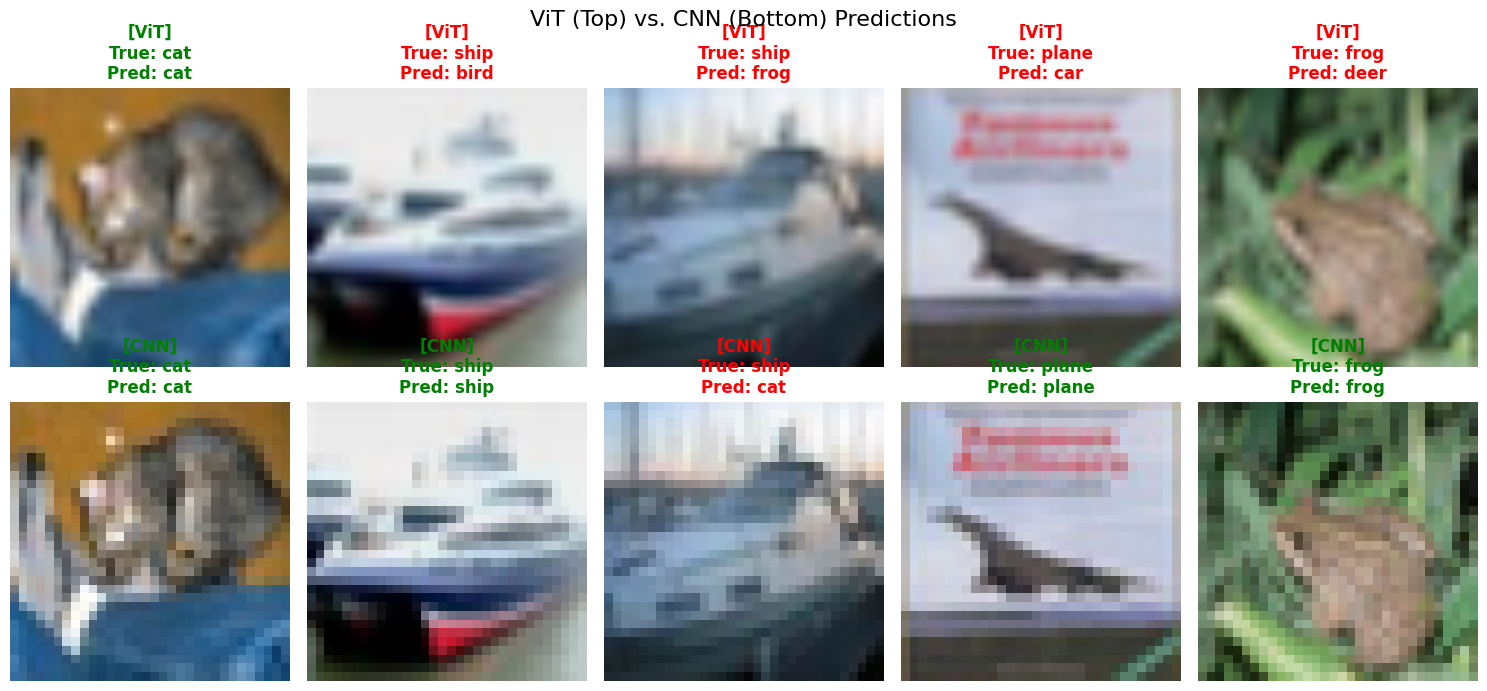

In [9]:
# Get Predictions for the First 5 Images
dataiter_vit = iter(loader_vit)
images_vit, labels = next(dataiter_vit)
images_vit = images_vit.to(device)

dataiter_cnn = iter(loader_cnn)
images_cnn, _ = next(dataiter_cnn) # Labels are same as above
images_cnn = images_cnn.to(device)

# Run Inference
with torch.no_grad():
    # ViT Prediction
    out_vit = vit_model(images_vit)
    _, preds_vit = torch.max(out_vit, 1)

    # CNN Prediction
    out_cnn = cnn_model(images_cnn)
    _, preds_cnn = torch.max(out_cnn, 1)

# Visualization
def imshow(img, ax):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.axis('off')

print("\nPredictions")
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("ViT (Top) vs. CNN (Bottom) Predictions", fontsize=16)

# Move images back to CPU for plotting
images_vit = images_vit.cpu()
images_cnn = images_cnn.cpu()

for i in range(5):
    # Top Row: ViT Results
    ax_vit = axes[0, i]
    imshow(images_vit[i], ax_vit)

    true_label = classes[labels[i]]
    vit_pred = classes[preds_vit[i]]

    # Green if correct, Red if wrong
    color = 'green' if vit_pred == true_label else 'red'
    ax_vit.set_title(f"[ViT]\nTrue: {true_label}\nPred: {vit_pred}", color=color, fontweight='bold')

    # Bottom Row: CNN Results
    ax_cnn = axes[1, i]
    imshow(images_cnn[i], ax_cnn)

    cnn_pred = classes[preds_cnn[i]]
    color = 'green' if cnn_pred == true_label else 'red'
    ax_cnn.set_title(f"[CNN]\nTrue: {true_label}\nPred: {cnn_pred}", color=color, fontweight='bold')

plt.tight_layout()
plt.show()